In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load DataSet

In [91]:
df = pd.read_csv(
    'fra.txt',
    sep = '\t',
    usecols = [0, 1],
    names = ['English', 'French']
)

df = df.iloc[: 10000]
df["French"] = df["French"].apply(
    lambda x: "<start> " + x + " <end>"
)

In [92]:
df.head()

,English,French
0,Go.,<start> Va ! <end>
1,Go.,<start> Marche. <end>
2,Go.,<start> En route ! <end>
3,Go.,<start> Bouge ! <end>
4,Hi.,<start> Salut ! <end>


### Train Test Split

In [93]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

print("Training pairs:", len(train_df))
print("Testing pairs:", len(test_df))

Training pairs: 8000
Testing pairs: 2000


In [94]:
english_sentence = train_df["English"].values
french_sentence = train_df["French"].values

### Tokenization

In [95]:
from tensorflow.keras.preprocessing.text import Tokenizer

# English
eng_tokenizer = Tokenizer()
eng_tokenizer.fit_on_texts(english_sentence)
encoder_input = eng_tokenizer.texts_to_sequences(english_sentence)

# French
fre_tokenizer = Tokenizer(filters = '')
fre_tokenizer.fit_on_texts(french_sentence)
decoder_input = fre_tokenizer.texts_to_sequences(french_sentence)

### Add Padding

In [96]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoder_input = pad_sequences(encoder_input, padding='post')
decoder_input = pad_sequences(decoder_input, padding='post')

### Vocabulary Size

In [97]:
eng_vocab_size = len(eng_tokenizer.word_index)+1
fre_vocab_size = len(fre_tokenizer.word_index)+1

print("English : ", eng_vocab_size)
print("French : ", fre_vocab_size)

English :  1904
French :  4928


### Max Length

In [98]:
max_encoder = encoder_input.shape[1]
max_decoder = decoder_input.shape[1]

print("Max Encoder : ", max_encoder)
print("Max Decoder : ", max_decoder)

Max Encoder :  4
Max Decoder :  12


# Transformer Archeticture

In [99]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model, Sequential

## Encoder Archeticture

In [100]:
encoder_inputs = Input(shape = (max_encoder,))
encoder_embedding = Embedding(input_dim=eng_vocab_size, output_dim=128)(encoder_inputs)

### Positional Encoding

In [101]:
position = tf.range(start=0, limit=max_encoder, delta=1)
positional_embedding = Embedding(input_dim = max_encoder, output_dim=128)(position)

# Add Encoder Embedding + Positional Encoder
x = encoder_embedding + positional_embedding

### Apply Masked Multi-Head Attention

In [102]:
encoder_attention = MultiHeadAttention(num_heads=4, key_dim=128)(x, x)

### Adds & Normalize

In [103]:
encoder_add = x + encoder_attention
encoder_norm = LayerNormalization()(encoder_add)

In [104]:
# Tell This Section your Encoder and Decoder is Same

### Feed-Forward Archeticture

In [105]:
encoder_ffn = Dense(256, activation='relu')(encoder_norm)
encoder_output = Dense(128)(encoder_ffn)

In [106]:
# Input
#   ↓
# Embedding
#   ↓
# Multi-Head Self-Attention
#   ↓
# Add & Norm
#   ↓
# Feed Forward
#   ↓
# Output

## Decoder Archeticture

In [107]:
decoder_inputs = Input(shape = (max_decoder, ))
decoder_embedding = Embedding(input_dim = fre_vocab_size, output_dim=128)(decoder_inputs)

### Positional Encoding

In [108]:
decoder_position = tf.range(start=0, limit=max_decoder, delta=1)
decoder_position_embedding = Embedding(input_dim=max_decoder, output_dim=128)(decoder_position)

# Add Decoder Embedding + Positional Encoding
decode_x = decoder_embedding + decoder_position_embedding

### Decoder Multi-Head Attention

In [109]:
# Keras uses the first decode_pos as Query and the second decode_poszz as Key; And Value defaults to the same tensor.
decoder_attention = MultiHeadAttention(num_heads=4, key_dim=128)(decode_x, decode_x, use_causal_mask=True)

### Add & Normalization

In [110]:
decoder_add = decoder_embedding + decoder_attention
decoder_norm = LayerNormalization()(decoder_add)

### Cross Attention

In [111]:
cross_attention = MultiHeadAttention(num_heads=4, key_dim=128)(decoder_norm, encoder_output)

In [112]:
decoder_add_2 = decoder_norm + cross_attention
decoder_norm_2 = LayerNormalization()(decoder_add_2)

### Feed-Forward Network

In [113]:
decoder_ffn = Dense(256, activation='relu')(decoder_norm_2)
decoder_output = Dense(128)(decoder_ffn)

### Output Layer

In [114]:
output = Dense(fre_vocab_size, activation='softmax')(decoder_output)

### Complete Model

In [115]:
complete_model = Model(
    [encoder_inputs, decoder_inputs],
    output
)

complete_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 4, 128)    │    243,712 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 12)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 4, 128)    │          0 │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 12, 128)   │    630,784 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 4, 128)    │    263,808 │ add_10[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 12, 128)   │          0 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 4, 128)    │          0 │ add_10[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │    263,808 │ add_12[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 4, 128)    │        256 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 12, 128)   │          0 │ embedding_11[0][… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 4, 256)    │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_13[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 4, 128)    │     32,896 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 12, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_14[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 12, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,434,240 (9.29 MB)

 Trainable params: 2,434,240 (9.29 MB)

 Non-trainable params: 0 (0.00 B)

### Model Compilation

In [116]:
complete_model.compile(optimizer = 'adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

### Deocoder Target

In [117]:
decoder_target = np.zeros_like(decoder_input)
decoder_target[:, :-1] = decoder_input[:, 1:]
decoder_target = np.expand_dims(decoder_target, -1)

### Model Fitting

In [118]:
history = complete_model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    epochs=5,
    batch_size = 32,
    validation_split=0.2
)

Epoch 1/5


200/200 ━━━━━━━━━━━━━━━━━━━━ 45s 174ms/step - accuracy: 0.7114 - loss: 2.5670 - val_accuracy: 0.8003 - val_loss: 1.3608
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 228ms/step - accuracy: 0.8134 - loss: 1.1743 - val_accuracy: 0.8192 - val_loss: 1.1928
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 46s 231ms/step - accuracy: 0.8425 - loss: 0.8678 - val_accuracy: 0.8317 - val_loss: 1.1364
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 76s 197ms/step - accuracy: 0.8602 - loss: 0.6728 - val_accuracy: 0.8369 - val_loss: 1.1259
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 44s 210ms/step - accuracy: 0.8812 - loss: 0.5176 - val_accuracy: 0.8403 - val_loss: 1.1694


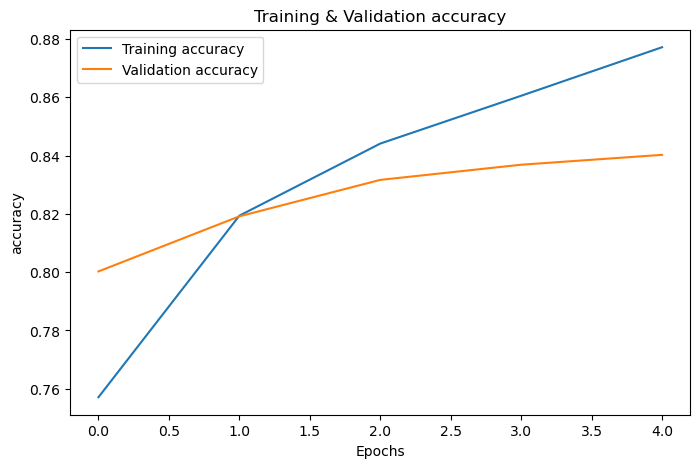

In [119]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("accuracy")
plt.title("Training & Validation accuracy")
plt.legend()
plt.show()

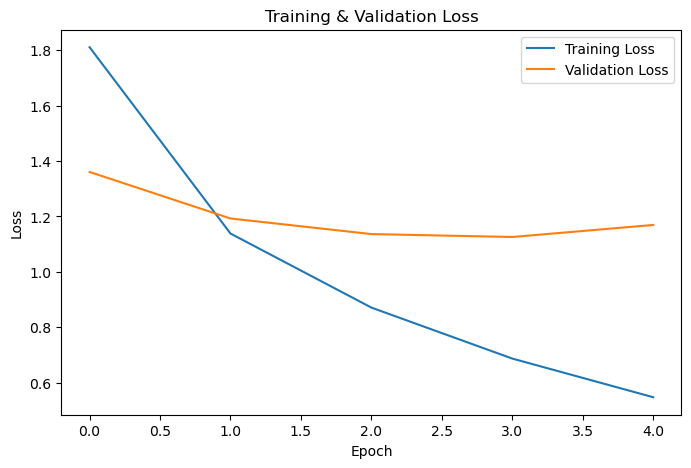

In [120]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.show()

## New Sentence Prediction

In [121]:
def translate_sentence(sentence):

    # English → tokens
    encoder_seq = eng_tokenizer.texts_to_sequences([sentence])

    encoder_seq = tf.keras.preprocessing.sequence.pad_sequences(
        encoder_seq,
        maxlen=max_encoder,
        padding="post"
    )

    # Start with <start>
    start_token = fre_tokenizer.word_index["<start>"]
    end_token = fre_tokenizer.word_index["<end>"]

    decoder_seq = [start_token]

    for _ in range(max_decoder - 1):

        decoder_input_test = tf.keras.preprocessing.sequence.pad_sequences(
            [decoder_seq],
            maxlen=max_decoder,
            padding="post"
        )

        prediction = complete_model.predict(
            [encoder_seq, decoder_input_test],
            verbose=0
        )

        # Get prediction for the current position
        next_token = np.argmax(
            prediction[0, len(decoder_seq) - 1, :]
        )

        # Stop when <end> is predicted
        if next_token == end_token:
            break

        decoder_seq.append(next_token)

    # Token IDs → French words
    index_word = {
        value: key
        for key, value in fre_tokenizer.word_index.items()
    }

    translated_words = [
        index_word.get(token, "")
        for token in decoder_seq[1:]
    ]

    return " ".join(translated_words)

In [122]:
sentence = "I am a student."

translation = translate_sentence(sentence)

print("English:", sentence)
print("French:", translation)

English: I am a student.
French: je suis un risque.


In [123]:
print(translate_sentence("How are you?"))
print(translate_sentence("I love you."))
print(translate_sentence("What is your name?"))
print(translate_sentence("I am learning artificial intelligence."))

comment allez-vous ?
je vous ai sauvés.
quelle sagesse !
je suis divorcé.
